In [2]:
## 基础工具
import numpy as np
import pandas as pd
import warnings
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import jn
# from IPython.display import display, clear_output
import time

# warnings.filterwarnings('ignore')
# %matplotlib inline

## 模型预测的
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 数据降维处理的
from sklearn.decomposition import PCA, FastICA, FactorAnalysis, SparsePCA

import lightgbm as lgb
import xgboost as xgb

## 参数搜索和评价的
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 通过Pandas对于数据进行读取 (pandas是一个很友好的数据读取函数库)
Train_data = pd.read_csv('datalab/used_car_train_20200313.csv', sep=' ')
TestB_data = pd.read_csv('datalab/used_car_testB_20200421.csv', sep=' ')

## 输出数据的大小信息
print('Train data shape:', Train_data.shape)
print('TestB data shape:', TestB_data.shape)
## 通过.head() 简要浏览读取数据的形式
Train_data.head()
## 通过 .info() 简要可以看到对应一些数据列名，以及NAN缺失信息
Train_data.info()
## 通过 .columns 查看列名
Train_data.columns
TestB_data.info()
## 通过 .describe() 可以查看数值特征列的一些统计信息
Train_data.describe()
TestB_data.describe()
numerical_cols = Train_data.select_dtypes(exclude='object').columns
print(numerical_cols)
categorical_cols = Train_data.select_dtypes(include='object').columns
print(categorical_cols)

Train data shape: (150000, 31)
TestB data shape: (50000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              149999 non-null  float64
 4   brand              150000 non-null  int64  
 5   bodyType           145494 non-null  float64
 6   fuelType           141320 non-null  float64
 7   gearbox            144019 non-null  float64
 8   power              150000 non-null  int64  
 9   kilometer          150000 non-null  float64
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  int64  
 14  creatDate          150000 non-null  int

X train shape: (150000, 18)
X test shape: (50000, 18)
Sta of label:
_min 11
_max: 99999
_mean 5923.327333333334
_ptp 99988
_std 7501.973469876438
_var 56279605.94272992


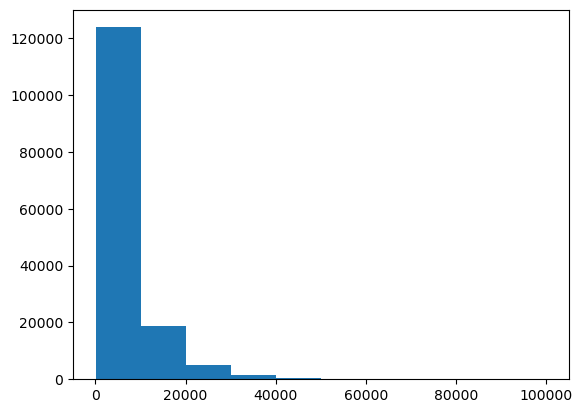

In [3]:
## 选择特征列
feature_cols = [col for col in numerical_cols if
                col not in ['SaleID', 'name', 'regDate', 'creatDate', 'price', 'model', 'brand', 'regionCode',
                            'seller']]
feature_cols = [col for col in feature_cols if 'Type' not in col]

## 提前特征列，标签列构造训练样本和测试样本
X_data = Train_data[feature_cols]
Y_data = Train_data['price']

X_test = TestB_data[feature_cols]

print('X train shape:', X_data.shape)
print('X test shape:', X_test.shape)


## 定义了一个统计函数，方便后续信息统计
def Sta_inf(data):
    print('_min', np.min(data))
    print('_max:', np.max(data))
    print('_mean', np.mean(data))
    print('_ptp', np.ptp(data))
    print('_std', np.std(data))
    print('_var', np.var(data))


print('Sta of label:')
Sta_inf(Y_data)
## 绘制标签的统计图，查看标签分布
plt.hist(Y_data)
plt.show()
plt.close()
X_data = X_data.fillna(-1)
X_test = X_test.fillna(-1)

In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

features = pd.get_dummies(X_data)
feature_names = list(features.columns)
features = np.array(features)
labels = np.array(Y_data).reshape((-1,))
feature_importance_values = np.zeros(len(feature_names))
task = 'regression'
early_stopping = True
eval_metric = 'l2'
n_iterations = 10
for _ in range(n_iterations):
    if task == 'classification':
        model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, verbose=-1)
    elif task == 'regression':
        model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1)
    else:
        raise ValueError('Task must be either "classification" or "regression"')

    model.fit(features, labels)
    # Record the feature importances
    feature_importance_values += model.feature_importances_ / n_iterations
    feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importance_values})

In [5]:
# 按照重要性大小对特征进行排序
feature_importances = feature_importances.sort_values('importance', ascending=False).reset_index(drop=True)
# 计算特征的相对重要性，全部特征的相对重要性之和为1
feature_importances['normalized_importance'] = feature_importances['importance'] / feature_importances[
    'importance'].sum()
# 计算特征的累计重要性
feature_importances['cumulative_importance'] = np.cumsum(feature_importances['normalized_importance'])
# 选取累计重要性大于0.99的特征，这些特征将会被删除掉。
drop_columns = list(feature_importances.query('cumulative_importance>0.99')['feature'])
# 去掉重要度低的列
x_set = X_data.copy()
x_set.drop(drop_columns, axis=1, inplace=True)
# 对数据集总体概览
x_set.info()
x_set.fillna(1, inplace=True)
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_set, Y_data)
from sklearn.metrics import mean_squared_error, mean_absolute_error


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   power      150000 non-null  int64  
 1   kilometer  150000 non-null  float64
 2   v_0        150000 non-null  float64
 3   v_1        150000 non-null  float64
 4   v_2        150000 non-null  float64
 5   v_3        150000 non-null  float64
 6   v_4        150000 non-null  float64
 7   v_5        150000 non-null  float64
 8   v_6        150000 non-null  float64
 9   v_7        150000 non-null  float64
 10  v_8        150000 non-null  float64
 11  v_10       150000 non-null  float64
 12  v_11       150000 non-null  float64
 13  v_12       150000 non-null  float64
 14  v_13       150000 non-null  float64
 15  v_14       150000 non-null  float64
dtypes: float64(15), int64(1)
memory usage: 18.3 MB


In [6]:
def model_goodness(model, x, y):
    prediction = model.predict(x)
    mae = mean_absolute_error(y, prediction)
    mse = mean_squared_error(y, prediction)
    rmse = np.sqrt(mse)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)


from sklearn.model_selection import cross_val_score


def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())



In [7]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(x_set, Y_data)
model_goodness(forest_reg, x_set, Y_data)
model_goodness(forest_reg, x_set, Y_data)
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor()
gbrt.fit(x_set, Y_data)
import lightgbm as lgb
import xgboost as xgb

xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(x_set, Y_data)
model_goodness(xgb_reg, x_set, Y_data)
lgb_reg = lgb.LGBMRegressor()
lgb_reg.fit(X_data, Y_data)
from sklearn.model_selection import RandomizedSearchCV
# 2.设置参数空间
from hyperopt import hp

space_forest = {
    'bootstrap': [True, False],
    'max_features': list(range(0, 25, 1)),
    'max_depth': list(range(0, 100, 1)),
    'n_estimators': list(range(30, 150, 1))
}
# 随机搜索，利用5折交叉验证得分来作为模型优劣的判断标准
forest_reg = RandomForestRegressor()
random_search = RandomizedSearchCV(forest_reg, space_forest, cv=5, scoring='neg_mean_squared_error')
# 2.定义参数空间

space = {
    'num_leaves': hp.quniform('num_leaves', 30, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample_for_bin': hp.quniform('subsample_for_bin', 20000, 300000, 20000),
    'max_depth': hp.quniform('max_depth', 0, 100, 1),
    'n_estimators': hp.quniform('n_estimators', 30, 150, 1)
}

MAE: 243.87631058829507
MSE: 307580.66866096394
RMSE: 554.5995570327874
MAE: 243.87631058829507
MSE: 307580.66866096394
RMSE: 554.5995570327874
MAE: 630.6511886390706
MSE: 1167607.1558260114
RMSE: 1080.5587239137035
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4097
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 18
[LightGBM] [Info] Start training from score 5923.327333


In [8]:
# 定义优化函数，即为5折交叉验证的得分
from sklearn.model_selection import cross_val_score


def objective(params, n_folds=5):
    num_leaf = int(params['num_leaves'])
    estimator = int(params['n_estimators'])
    rate = params['learning_rate']
    sub_for_bin = int(params['subsample_for_bin'])
    max_dep = int(params['max_depth'])
    lgb_reg = lgb.LGBMRegressor(num_leaves=num_leaf, n_estimators=estimator, learning_rate=rate,
                                subsample_for_bin=sub_for_bin, max_depth=max_dep)
    lgb_reg.fit(x_set, Y_data)
    scores = cross_val_score(lgb_reg, x_set, Y_data, scoring='neg_mean_absolute_error', cv=5)
    mae_scores = np.abs(scores)
    loss = mae_scores.mean()
    return loss


# 寻找到使优化函数最小超参数组合，利用hyperopt中的fmin来求最小化
from hyperopt import Trials, fmin, tpe

#best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=500)


In [9]:
# 构造调优后的模型
forest_reg = RandomForestRegressor(n_estimators=73, max_features=11, max_depth=33, bootstrap=False)
xgb_reg = xgb.XGBRegressor(colsample_bytree=0.8400547784951151, gamma=0.24562245606367,
                           learning_rate=0.07356238705262594, max_depth=13, n_estimators=135)
lgb_reg = lgb.LGBMRegressor(learning_rate=0.1281370851088587, max_depth=24, n_estimators=148, num_leaves=146,
                            subsample_for_bin=200000)

In [10]:
# 将训练集切分出验证集
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Split data with val
x_train, x_val, y_train, y_val = train_test_split(X_data, Y_data, test_size=0.3)


In [11]:
# 模型训练
forest_reg.fit(x_train, y_train)
xgb_reg.fit(x_train, y_train)
lgb_reg.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4097
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 18
[LightGBM] [Info] Start training from score 5921.009590


LGBMRegressor(learning_rate=0.1281370851088587, max_depth=24, n_estimators=148,
              num_leaves=146)

In [12]:
# 用验证集进行预测
forest_pre = forest_reg.predict(x_val)
xgb_pre = xgb_reg.predict(x_val)
lgb_pre = lgb_reg.predict(x_val)

In [13]:
#构造调优后的模型
forest_reg1=RandomForestRegressor(n_estimators=73, max_features= 11, max_depth=33,bootstrap=False)
xgb_reg1=xgb.XGBRegressor(colsample_bytree=0.8400547784951151,gamma=0.24562245606367,learning_rate=0.07356238705262594,max_depth=13,n_estimators=135)
lgb_reg1=lgb.LGBMRegressor(learning_rate=0.1281370851088587,max_depth=24,n_estimators=148,num_leaves=146,subsample_for_bin=200000)

In [14]:
#模型训练
forest_reg1.fit(X_data, Y_data)
xgb_reg1.fit(X_data, Y_data)
lgb_reg1.fit(X_data, Y_data)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4097
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 18
[LightGBM] [Info] Start training from score 5923.327333


LGBMRegressor(learning_rate=0.1281370851088587, max_depth=24, n_estimators=148,
              num_leaves=146)

In [15]:
#用验证集进行预测
forest_pre1=forest_reg1.predict(X_test)
xgb_pre1=xgb_reg1.predict(X_test)
lgb_pre1=lgb_reg1.predict(X_test)

In [16]:
# 输出预测结果的MAE
MAE_forest = mean_absolute_error(forest_pre, y_val)
MAE_xgb = mean_absolute_error(xgb_pre, y_val)
MAE_lgb = mean_absolute_error(lgb_pre, y_val)
print('MAE for RandomForest:', MAE_forest)
print('MAE for xgb:', MAE_xgb)
print('MAE for lgb:', MAE_lgb)

MAE for RandomForest: 661.2572505872499
MAE for xgb: 658.5031508739684
MAE for lgb: 684.2208280853774


In [20]:
# 采用加权融合模型
val_Weighted = (1 - 2 * MAE_lgb / (MAE_xgb + MAE_lgb + MAE_forest)) * lgb_pre + (
            1 - 2 * MAE_xgb / (MAE_xgb + MAE_lgb + MAE_forest)) * xgb_pre + (
                           1 - 2 * MAE_forest / (MAE_xgb + MAE_lgb + MAE_forest)) * forest_pre
print('MAE for val_Weighted:', mean_absolute_error(val_Weighted, y_val))
val_Weighted[val_Weighted<0]=10 # 对预测值进行修正

MAE for val_Weighted: 644.0992475404989


In [22]:
val_Weighted = (1 - 2 * MAE_lgb / (MAE_xgb + MAE_lgb + MAE_forest)) * lgb_pre1 + (
            1 - 2 * MAE_xgb / (MAE_xgb + MAE_lgb + MAE_forest)) * xgb_pre1 + (
                           1 - 2 * MAE_forest / (MAE_xgb + MAE_lgb + MAE_forest)) * forest_pre1


In [29]:
# 输出预测结果
sub = pd.DataFrame()
sub['SaleID'] = TestB_data.SaleID
sub['price'] = val_Weighted
sub.to_csv('./sub_Weighted.csv',index=False)

In [30]:
sub.head()

,SaleID,price
0,200000,1235.127887
1,200001,1739.387110
2,200002,8303.113045
3,200003,1064.966828
4,200004,2048.412359


In [31]:
print('测试集长度:', len(val_Weighted))

测试集长度: 50000


In [ ]:
print('MAE for val_Weighted:', mean_absolute_error(val_Weighted, y_val))